# Phase 5 — Transformer seq2seq (Encoder-Decoder)

Full Transformer encoder-decoder for GEC, trained on the same 1M-sample budget as Phases 3 and 4.
No recurrence — the model processes the entire source sequence in parallel via self-attention,
and uses cross-attention (encoder-decoder attention) in every decoder layer instead of a single
Bahdanau vector.

**Architecture:**
- Shared BPE embedding (16k) + sinusoidal positional encoding
- 3-layer Transformer encoder (d_model=256, nhead=8, FFN=512)
- 3-layer Transformer decoder (same dims) with causal masking + cross-attention
- Weight-tied output projection (output linear shares weights with embedding)

**Training:**
- Inverse-sqrt warmup schedule (warmup_steps=4000) from "Attention Is All You Need"
- Label smoothing ε=0.1
- Mixed precision (AMP), grad clip 1.0
- 10 epochs, early stopping on val GLEU

**Inputs:** same tokenizer and splits as Phases 3 & 4  
**Targets:** beat Phase 4 GLEU; visualise cross-attention and encoder self-attention heatmaps

In [1]:
!pip install tokenizers nltk -q
import nltk; nltk.download("punkt", quiet=True)

import os, math, time, random, json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tokenizers import ByteLevelBPETokenizer
from nltk.translate.gleu_score import corpus_gleu

SEED = 42
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| Torch:", torch.__version__)

Device: cuda | Torch: 2.10.0+cu128


In [2]:
assert torch.cuda.is_available(), "No GPU. Settings -> Accelerator -> GPU T4 x2."
print("Device :", torch.cuda.get_device_name(0))
print("VRAM   :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
_x = torch.randn(8, 8, device="cuda") @ torch.randn(8, 8, device="cuda")
print("CUDA kernel test OK, sum =", round(_x.sum().item(), 3))

Device : Tesla T4
VRAM   : 15.6 GB
CUDA kernel test OK, sum = -11.377


## 1. Paths and config

Same 1M data budget as Phases 3 and 4: **850k train / 50k val / 100k test**.
All hyperparameters live in `CFG`. `RUN_MODE` toggles smoke/dev/final.

Key transformer-specific fields:
- `d_model`: embedding dimension and throughout the model (256)
- `nhead`: number of attention heads (8); each head has dimension d_model/nhead = 32
- `num_enc_layers` / `num_dec_layers`: depth of encoder and decoder stacks
- `dim_ffn`: inner dimension of the position-wise feed-forward sublayer (512 = 2 × d_model)
- `warmup_steps`: steps for inverse-sqrt LR warmup (4000, as in the original paper)
- `label_smooth`: label smoothing ε — prevents overconfident predictions

In [ ]:
DATA_DIR  = "/kaggle/input/datasets/ibrahimhany202200518/gec-c4-5m-splits/data"
TOKEN_DIR = "/kaggle/input/datasets/ibrahimhany202200518/gec-bpe-tokenizer/tokenizer"
PH3_DIR   = "/kaggle/input/datasets/ibrahimhany202200518/gec-phase3-lstm-noattn/lstm_noattn"
PH4_DIR   = "/kaggle/input/datasets/ibrahimhany202200518/lstm-att/lstm_bahdanau_final"

CFG = {
    "vocab_size":      16000,
    "d_model":         256,
    "nhead":           8,
    "num_enc_layers":  3,
    "num_dec_layers":  3,
    "dim_ffn":         512,
    "dropout":         0.1,
    "max_len":         64,
    "batch_size":      64,
    "lr_peak":         1e-3,
    "warmup_steps":    4000,
    "weight_decay":    1e-4,
    "clip":            1.0,
    "label_smooth":    0.1,
    # training
    "epochs":          10,
    "log_every":       200,
    "ckpt_every":      2000,
    # data caps — 1M total
    "max_train":       850_000,
    "max_val":         50_000,
    "max_test":        100_000,
    "max_val_eval":    5_000,
    "max_beam_eval":   2_000,
}

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

RUN_MODE = "final"   # "smoke" | "dev" | "final"
CFG["max_train"]  = {"smoke": 10_000, "dev": 100_000, "final": 850_000}[RUN_MODE]
CFG["max_val"]    = {"smoke":  2_000, "dev":  10_000, "final":  50_000}[RUN_MODE]
CFG["max_test"]   = {"smoke":  2_000, "dev":  10_000, "final": 100_000}[RUN_MODE]
CFG["epochs"]     = {"smoke": 1,      "dev":  3,      "final": 10}[RUN_MODE]

OUT_DIR = f"/kaggle/working/transformer_{RUN_MODE}"
os.makedirs(OUT_DIR, exist_ok=True)
print("Mode:", RUN_MODE, "| OUT_DIR:", OUT_DIR)
print(f"Budget: train={CFG['max_train']:,}  val={CFG['max_val']:,}  "
      f"test={CFG['max_test']:,}  total={CFG['max_train']+CFG['max_val']+CFG['max_test']:,}")

Mode: final | OUT_DIR: /kaggle/working/transformer_final
Budget: train=850,000  val=50,000  test=100,000  total=1,000,000


## 2. Load tokenizer

Reload the 16k ByteLevel BPE tokenizer from Phase 1. Identical to Phases 3 and 4.

In [4]:
tokenizer = ByteLevelBPETokenizer(
    f"{TOKEN_DIR}/vocab.json",
    f"{TOKEN_DIR}/merges.txt",
)
tokenizer.add_special_tokens(["<pad>", "<unk>", "<s>", "</s>"])
assert tokenizer.token_to_id("<pad>") == PAD_ID
assert tokenizer.token_to_id("<s>")   == BOS_ID
assert tokenizer.token_to_id("</s>")  == EOS_ID
print("Vocab size:", tokenizer.get_vocab_size())

Vocab size: 16000


## 3. Dataset and collate

Identical to Phase 4. `GECDataset` lazy-loads `(corrupted, clean)` pairs.
Encoder input has no special tokens; decoder target wrapped as `[<s>, …, </s>]`.
`collate` pads each batch dynamically to the longest sequence in that batch.

In [5]:
class GECDataset(Dataset):
    def __init__(self, path, tokenizer, max_len=64, limit=None):
        self.pairs = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) != 2:
                    continue
                self.pairs.append((parts[0], parts[1]))
                if limit is not None and len(self.pairs) >= limit:
                    break
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        src, tgt = self.pairs[i]
        src_ids = self.tok.encode(src).ids[: self.max_len]
        tgt_ids = self.tok.encode(tgt).ids[: self.max_len - 2]
        tgt_ids = [BOS_ID] + tgt_ids + [EOS_ID]
        if len(src_ids) == 0:
            src_ids = [UNK_ID]
        return (torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long))


def collate(batch):
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs], dtype=torch.long)
    tgt_lens = torch.tensor([len(t) for t in tgts], dtype=torch.long)
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_ID)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_ID)
    return src_pad, src_lens, tgt_pad, tgt_lens


train_ds = GECDataset(f"{DATA_DIR}/train.tsv", tokenizer, CFG["max_len"], CFG["max_train"])
val_ds   = GECDataset(f"{DATA_DIR}/val.tsv",   tokenizer, CFG["max_len"], CFG["max_val"])
test_ds  = GECDataset(f"{DATA_DIR}/test.tsv",  tokenizer, CFG["max_len"], CFG["max_test"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=collate)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate)

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")
print(f"Total: {len(train_ds)+len(val_ds)+len(test_ds):,}")
print("steps/epoch:", len(train_loader),
      "| total steps:", len(train_loader) * CFG["epochs"])

Train: 850,000  Val: 50,000  Test: 85,000
Total: 985,000
steps/epoch: 13282 | total steps: 132820


## 4. Model

### PositionalEncoding
Transformers have no recurrence, so they cannot know token order unless we inject it.
We add sinusoidal positional encodings to the embeddings:
```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```
These are fixed (not learned). Each position gets a unique fingerprint across all
embedding dimensions. The model can learn to use the relative-position signal because
`sin(a+b)` and `cos(a+b)` are linear functions of `sin(a)`, `cos(a)`, `sin(b)`, `cos(b)`.

### TransformerGEC
Built around PyTorch's `nn.Transformer` (batch_first=True):
- **src** path: embed → scale by √d_model → add PE → 3-layer encoder
- **tgt** path: embed → scale → add PE → 3-layer decoder (causal mask + cross-attention)
- **Output**: linear(d_model → vocab_size), weight-tied to the embedding matrix

**Weight tying** — the embedding matrix (vocab × d_model) and the output projection
matrix (d_model → vocab) both map between token indices and vector space.
Sharing them halves that parameter cost (~4M params) and regularises training.

**Masks**:
- `tgt_mask`: upper-triangular causal mask — decoder position t cannot attend to t+1, t+2, …
- `src_key_padding_mask`: (B, S) True at PAD positions in source — encoder ignores padding
- `memory_key_padding_mask`: same mask forwarded to decoder cross-attention
- `tgt_key_padding_mask`: (B, T) True at PAD in decoder input

The model exposes `encode()` and `decode_step()` for use in beam search without
re-encoding the source at every step.

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)                      # (max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))             # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

In [ ]:
class TransformerGEC(nn.Module):
    def __init__(self, vocab_size, d_model, nhead,
                 num_enc_layers, num_dec_layers, dim_ffn,
                 dropout, max_len, pad_id=PAD_ID):
        super().__init__()
        self.d_model = d_model
        self.pad_id  = pad_id

        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc = PositionalEncoding(d_model, dropout, max_len + 2)

        self.transformer = nn.Transformer(
            d_model          = d_model,
            nhead            = nhead,
            num_encoder_layers = num_enc_layers,
            num_decoder_layers = num_dec_layers,
            dim_feedforward  = dim_ffn,
            dropout          = dropout,
            batch_first      = True,
        )

        self.out = nn.Linear(d_model, vocab_size, bias=False)
        self.out.weight = self.embed.weight   # weight tying

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)


    def _causal_mask(self, sz):
        return nn.Transformer.generate_square_subsequent_mask(sz, device=DEVICE)

    def _pad_mask(self, x):
        return x == self.pad_id   # (B, T), True at PAD



    def forward(self, src, tgt_in):
        src_pm = self._pad_mask(src)          # (B, S)
        tgt_pm = self._pad_mask(tgt_in)       # (B, T)
        tgt_cm = self._causal_mask(tgt_in.size(1))  # (T, T)

        src_emb = self.pos_enc(self.embed(src)    * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.embed(tgt_in) * math.sqrt(self.d_model))

        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask                = tgt_cm,
            src_key_padding_mask    = src_pm,
            tgt_key_padding_mask    = tgt_pm,
            memory_key_padding_mask = src_pm,
        )   # (B, T, d_model)
        return self.out(out)   # (B, T, vocab)



    def encode(self, src):
        src_pm  = self._pad_mask(src)
        src_emb = self.pos_enc(self.embed(src) * math.sqrt(self.d_model))
        memory  = self.transformer.encoder(src_emb, src_key_padding_mask=src_pm)
        return memory, src_pm


    def decode_step(self, tgt_seq, memory, src_pm):
        T      = tgt_seq.size(1)
        tgt_cm = self._causal_mask(T)
        tgt_pm = self._pad_mask(tgt_seq)
        tgt_emb = self.pos_enc(self.embed(tgt_seq) * math.sqrt(self.d_model))
        out = self.transformer.decoder(
            tgt_emb, memory,
            tgt_mask                = tgt_cm,
            tgt_key_padding_mask    = tgt_pm,
            memory_key_padding_mask = src_pm,
        )   # (B, T, d_model)
        return self.out(out)   # (B, T, vocab)


    @torch.no_grad()
    def greedy_decode(self, src, max_len=64):
        self.eval()
        B = src.size(0)
        memory, src_pm = self.encode(src)
        ys = torch.full((B, 1), BOS_ID, dtype=torch.long, device=src.device)
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)

        for _ in range(max_len):
            logits   = self.decode_step(ys, memory, src_pm)   # (B, T, vocab)
            next_tok = logits[:, -1].argmax(-1)                # (B,)
            next_tok = torch.where(finished,
                                   torch.full_like(next_tok, PAD_ID), next_tok)
            ys       = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
            finished = finished | (next_tok == EOS_ID)
            if finished.all():
                break

        return ys[:, 1:]   # strip BOS


model = TransformerGEC(
    vocab_size     = CFG["vocab_size"],
    d_model        = CFG["d_model"],
    nhead          = CFG["nhead"],
    num_enc_layers = CFG["num_enc_layers"],
    num_dec_layers = CFG["num_dec_layers"],
    dim_ffn        = CFG["dim_ffn"],
    dropout        = CFG["dropout"],
    max_len        = CFG["max_len"],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params/1e6:.2f}M")

Trainable params: 8.05M


## 5. Optimizer, warmup scheduler, label-smoothing loss

### Why warmup?
At the start of training the model weights are random and the gradient variance is high.
Starting with a large learning rate causes the Adam second-moment estimates (v̂) to be
unreliable, leading to huge, destabilising updates. Warmup ramps the LR slowly up to
its peak so the first few thousand steps are conservative. Then the LR decays with an
inverse-square-root schedule:
```
lr = d_model^(-0.5) × min(step^(-0.5), step × warmup^(-1.5))
```
This is the exact formula from "Attention Is All You Need" (Vaswani et al., 2017).

### Why label smoothing?
Without it, the model is trained to assign probability 1 to the correct token and 0 to
all others. This encourages extreme logit values (overconfidence) and hurts generalisation.
Label smoothing ε=0.1 replaces the hard target with a soft distribution:
- correct token: 1 - ε + ε/V ≈ 0.9
- every other token: ε/V ≈ 6e-6

PyTorch CrossEntropyLoss accepts `label_smoothing` directly.

In [8]:
criterion = nn.CrossEntropyLoss(
    ignore_index   = PAD_ID,
    label_smoothing= CFG["label_smooth"],
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = 0.0,          # managed by scheduler
    betas        = (0.9, 0.98),
    eps          = 1e-9,
    weight_decay = CFG["weight_decay"],
)

scaler = torch.amp.GradScaler("cuda")


class WarmupInvSqrt:
    """Inverse-sqrt LR schedule with linear warmup (Vaswani et al. 2017)."""
    def __init__(self, optimizer, d_model, warmup_steps, peak_lr=None):
        self.opt          = optimizer
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        self.peak_lr      = peak_lr          # optional cap
        self._step        = 0

    def step(self):
        self._step += 1
        lr = self.d_model ** (-0.5) * min(
            self._step ** (-0.5),
            self._step * self.warmup_steps ** (-1.5)
        )
        if self.peak_lr is not None:
            lr = min(lr, self.peak_lr)
        for pg in self.opt.param_groups:
            pg["lr"] = lr
        return lr

    @property
    def current_lr(self):
        return self.opt.param_groups[0]["lr"]


lr_sched = WarmupInvSqrt(optimizer, CFG["d_model"],
                         CFG["warmup_steps"], CFG["lr_peak"])
print("Criterion:", criterion)
print("Optimizer :", optimizer)

Criterion: CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.98)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-09
    foreach: None
    fused: None
    lr: 0.0
    maximize: False
    weight_decay: 0.0001
)


## 5b. Sanity check — forward pass and mask shapes

In [9]:
_src, _src_lens, _tgt, _ = next(iter(val_loader))
_src, _tgt = _src.to(DEVICE), _tgt.to(DEVICE)
with torch.no_grad():
    _logits = model(_src, _tgt[:, :-1])
print("logits shape:", tuple(_logits.shape),
      "expected (B, T-1, vocab):", (CFG["batch_size"], _tgt.size(1)-1, CFG["vocab_size"]))
assert _logits.shape == (_src.size(0), _tgt.size(1)-1, CFG["vocab_size"]), "shape mismatch!"
print("Forward pass OK")
del _src, _src_lens, _tgt, _logits

logits shape: (64, 63, 16000) expected (B, T-1, vocab): (64, 63, 16000)
Forward pass OK


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


## 6. Validation — greedy decode + GLEU

Same structure as Phases 3 and 4. `max_batches` caps the greedy-decode portion to
`max_val_eval` samples so each epoch stays fast. Teacher-forced loss is still computed
over all val batches (loss is cheap; greedy decode is the slow part).

In [10]:
def ids_to_text(ids):
    out = []
    for i in ids:
        i = int(i)
        if i in (BOS_ID, PAD_ID):
            continue
        if i == EOS_ID:
            break
        out.append(i)
    return tokenizer.decode(out)


@torch.no_grad()
def evaluate_gleu(model, loader, max_batches=None):
    model.eval()
    refs, hyps = [], []
    total_loss, total_tokens = 0.0, 0
    for bi, (src, src_lens, tgt, tgt_lens) in enumerate(loader):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

        with autocast():
            logits = model(src, tgt_in)
            loss   = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        n_tok        = (tgt_out != PAD_ID).sum().item()
        total_loss   += loss.item() * n_tok
        total_tokens += n_tok

        if max_batches is None or bi < max_batches:
            gen = model.greedy_decode(src, max_len=CFG["max_len"])
            for g, t in zip(gen.cpu().tolist(), tgt.cpu().tolist()):
                hyps.append(ids_to_text(g).split())
                refs.append([ids_to_text(t).split()])

    avg_loss = total_loss / max(total_tokens, 1)
    gleu = corpus_gleu(refs, hyps) if refs else 0.0
    return avg_loss, gleu

## 7. Training loop

The LR scheduler is stepped **every batch** (not every epoch) because the warmup
schedule is defined in terms of gradient steps, not epochs. This differs from Phases 3 & 4
where `ReduceLROnPlateau` was stepped per epoch.

In [11]:
def save_ckpt(path, model, optimizer, lr_sched, step, epoch, best_gleu):
    torch.save({
        "model":     model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "lr_step":   lr_sched._step,
        "step":      step,
        "epoch":     epoch,
        "best_gleu": best_gleu,
        "cfg":       CFG,
    }, path)


def train_one_epoch(model, loader, epoch, global_step, best_gleu):
    model.train()
    running_loss, running_tokens = 0.0, 0
    t0 = time.time()

    for src, src_lens, tgt, tgt_lens in loader:
        src, tgt = src.to(DEVICE, non_blocking=True), tgt.to(DEVICE, non_blocking=True)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        lr = lr_sched.step()    # step LR before forward

        with autocast():
            logits = model(src, tgt_in)
            loss   = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["clip"])
        scaler.step(optimizer)
        scaler.update()

        n_tok          = (tgt_out != PAD_ID).sum().item()
        running_loss   += loss.item() * n_tok
        running_tokens += n_tok
        global_step    += 1

        if global_step % CFG["log_every"] == 0:
            cur = running_loss / max(running_tokens, 1)
            dt  = time.time() - t0
            print(f"  step {global_step:>7} | loss {cur:.4f} | ppl {math.exp(min(cur,20)):.1f}"
                  f" | lr {lr:.2e} | {dt:.0f}s")
            running_loss, running_tokens, t0 = 0.0, 0, time.time()

        if global_step % CFG["ckpt_every"] == 0:
            save_ckpt(f"{OUT_DIR}/last.pt",
                      model, optimizer, lr_sched, global_step, epoch, best_gleu)

    return global_step

In [12]:
best_gleu   = -1.0
global_step = 0
_eval_batches = CFG["max_val_eval"] // CFG["batch_size"]

for epoch in range(1, CFG["epochs"] + 1):
    print(f"\n=== Epoch {epoch}/{CFG['epochs']} ===")
    global_step = train_one_epoch(model, train_loader, epoch, global_step, best_gleu)

    print(f"Validating (greedy on first {CFG['max_val_eval']:,} val samples)...")
    val_loss, val_gleu = evaluate_gleu(model, val_loader, max_batches=_eval_batches)
    print(f"epoch {epoch}: val_loss={val_loss:.4f}  val_gleu={val_gleu:.4f}")

    save_ckpt(f"{OUT_DIR}/last.pt",
              model, optimizer, lr_sched, global_step, epoch, best_gleu)
    if val_gleu > best_gleu:
        best_gleu = val_gleu
        save_ckpt(f"{OUT_DIR}/best.pt",
                  model, optimizer, lr_sched, global_step, epoch, best_gleu)
        print(f"  -> new best GLEU={best_gleu:.4f}, saved to {OUT_DIR}/best.pt")


=== Epoch 1/10 ===


/tmp/ipykernel_23/2122822758.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  step     200 | loss 9.3272 | ppl 11239.6 | lr 4.94e-05 | 10s
  step     400 | loss 8.2038 | ppl 3654.9 | lr 9.88e-05 | 9s
  step     600 | loss 7.6946 | ppl 2196.4 | lr 1.48e-04 | 9s
  step     800 | loss 7.4066 | ppl 1646.8 | lr 1.98e-04 | 9s
  step    1000 | loss 7.0169 | ppl 1115.3 | lr 2.47e-04 | 9s
  step    1200 | loss 6.5790 | ppl 719.8 | lr 2.96e-04 | 9s
  step    1400 | loss 6.2333 | ppl 509.4 | lr 3.46e-04 | 9s
  step    1600 | loss 5.9027 | ppl 366.0 | lr 3.95e-04 | 9s
  step    1800 | loss 5.5795 | ppl 264.9 | lr 4.45e-04 | 9s
  step    2000 | loss 5.2763 | ppl 195.7 | lr 4.94e-04 | 9s
  step    2200 | loss 4.9559 | ppl 142.0 | lr 5.44e-04 | 9s
  step    2400 | loss 4.5643 | ppl 96.0 | lr 5.93e-04 | 9s
  step    2600 | loss 4.1664 | ppl 64.5 | lr 6.42e-04 | 9s
  step    2800 | loss 3.7932 | ppl 44.4 | lr 6.92e-04 | 9s
  step    3000 | loss 3.5184 | ppl 33.7 | lr 7.41e-04 | 9s
  step    3200 | loss 3.3397 | ppl 28.2 | lr 7.91e-04 | 9s
  step    3400 | loss 3.2214 | ppl 25.

/tmp/ipykernel_23/3927092295.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


epoch 1: val_loss=2.4933  val_gleu=0.6069
  -> new best GLEU=0.6069, saved to /kaggle/working/transformer_final/best.pt

=== Epoch 2/10 ===
  step   13400 | loss 2.4927 | ppl 12.1 | lr 5.40e-04 | 5s
  step   13600 | loss 2.4941 | ppl 12.1 | lr 5.36e-04 | 9s
  step   13800 | loss 2.4895 | ppl 12.1 | lr 5.32e-04 | 9s
  step   14000 | loss 2.5045 | ppl 12.2 | lr 5.28e-04 | 9s
  step   14200 | loss 2.4891 | ppl 12.1 | lr 5.24e-04 | 9s
  step   14400 | loss 2.4915 | ppl 12.1 | lr 5.21e-04 | 9s
  step   14600 | loss 2.4876 | ppl 12.0 | lr 5.17e-04 | 9s
  step   14800 | loss 2.4891 | ppl 12.1 | lr 5.14e-04 | 9s
  step   15000 | loss 2.4930 | ppl 12.1 | lr 5.10e-04 | 9s
  step   15200 | loss 2.4811 | ppl 12.0 | lr 5.07e-04 | 9s
  step   15400 | loss 2.4732 | ppl 11.9 | lr 5.04e-04 | 9s
  step   15600 | loss 2.4808 | ppl 12.0 | lr 5.00e-04 | 9s
  step   15800 | loss 2.4922 | ppl 12.1 | lr 4.97e-04 | 9s
  step   16000 | loss 2.4854 | ppl 12.0 | lr 4.94e-04 | 9s
  step   16200 | loss 2.4749 | ppl

## 8. Test set — greedy decoding

Load `best.pt`, decode the full test set greedily, save `(src, pred, ref)` TSV.

In [13]:
ckpt = torch.load(f"{OUT_DIR}/best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print("Loaded best from epoch", ckpt["epoch"], "step", ckpt["step"])

preds_greedy, refs_text, srcs_text = [], [], []
model.eval()
with torch.no_grad():
    for src, src_lens, tgt, tgt_lens in test_loader:
        src = src.to(DEVICE)
        gen = model.greedy_decode(src, max_len=CFG["max_len"])
        for s, g, t in zip(src.cpu().tolist(), gen.cpu().tolist(), tgt.tolist()):
            srcs_text.append(ids_to_text(s))
            preds_greedy.append(ids_to_text(g))
            refs_text.append(ids_to_text(t))

with open(f"{OUT_DIR}/test_predictions_greedy.tsv", "w", encoding="utf-8") as f:
    for s, p, r in zip(srcs_text, preds_greedy, refs_text):
        f.write(f"{s}\t{p}\t{r}\n")
print("Saved greedy predictions:", len(preds_greedy))

Loaded best from epoch 10 step 132820
Saved greedy predictions: 85000


## 8b. Test set — beam=4

Unlike the LSTM beam search (which re-uses the RNN hidden state), the Transformer
must pass the **full prefix** through the decoder at every step. We encode the source
once and cache `memory`; only the decoder re-runs per step.

Beam search maintains the `beam` most probable partial sequences at each step,
scores each candidate by length-normalised log-prob (α=0.7), and prunes to the top-k.

In [ ]:
@torch.no_grad()
def beam_decode_one(model, src_ids, beam=4, max_len=64, alpha=0.7):
    model.eval()
    src = src_ids.unsqueeze(0).to(DEVICE)    # (1, S)
    memory, src_pm = model.encode(src)

    # Each beam: (log_prob_sum, [token_ids], finished)
    beams = [(0.0, [BOS_ID], False)]

    for _ in range(max_len):
        new_beams = []
        all_done  = True
        for score, toks, fin in beams:
            if fin:
                new_beams.append((score, toks, fin))
                continue
            all_done = False
            tgt_seq  = torch.tensor([toks], device=DEVICE)          # (1, T)
            logits   = model.decode_step(tgt_seq, memory, src_pm)   # (1, T, vocab)
            log_prob = F.log_softmax(logits[0, -1], dim=-1)         # (vocab,)
            top_lp, top_ix = log_prob.topk(beam)
            for lp, ix in zip(top_lp.tolist(), top_ix.tolist()):
                new_beams.append((score + lp, toks + [ix], ix == EOS_ID))

        if all_done:
            break
        # length-normalised score, keep top-k
        new_beams.sort(key=lambda b: b[0] / (len(b[1]) ** alpha), reverse=True)
        beams = new_beams[:beam]

    return beams[0][1]   # best sequence token ids


# Beam decode is O(beam x seq_len x decode_steps) — cap to max_beam_eval samples.
_beam_n = min(len(test_ds), CFG["max_beam_eval"])
preds_beam = []
t0 = time.time()
for i in range(_beam_n):
    src, tgt = test_ds[i]
    out_ids = beam_decode_one(model, src, beam=4, max_len=CFG["max_len"])
    preds_beam.append(ids_to_text(out_ids))
    if (i + 1) % 500 == 0:
        print(f"  beam decoded {i+1}/{_beam_n}  ({time.time()-t0:.0f}s)")

with open(f"{OUT_DIR}/test_predictions_beam4.tsv", "w", encoding="utf-8") as f:
    for s, p, r in zip(srcs_text[:_beam_n], preds_beam, refs_text[:_beam_n]):
        f.write(f"{s}	{p}	{r}")
print(f"Saved beam=4 predictions: {len(preds_beam)} (capped — full test set uses greedy above)")


  beam decoded 500/2000  (232s)
  beam decoded 1000/2000  (467s)
  beam decoded 1500/2000  (711s)
  beam decoded 2000/2000  (942s)
Saved beam=4 predictions: 2000 (capped — full test set uses greedy above)


## 9. Metrics

Same four metrics as Phases 3 and 4 for direct comparison:

| Metric | What it measures |
|--------|------------------|
| **Exact-match** | output equals reference token-for-token |
| **GLEU** | n-gram overlap penalising unfixed source errors |
| **Precision / Recall / F0.5** | token-level; β=0.5 weights precision |
| **Length-bucketed EM** | exact-match split by reference length |

In [15]:
from collections import Counter


def exact_match(preds, refs):
    return sum(p.strip() == r.strip() for p, r in zip(preds, refs)) / len(preds)


def token_prf(preds, refs, beta=0.5):
    tp = fp = fn = 0
    for p, r in zip(preds, refs):
        pc, rc = Counter(p.split()), Counter(r.split())
        for tok, n in pc.items():
            tp += min(n, rc.get(tok, 0))
            fp += max(0, n - rc.get(tok, 0))
        for tok, n in rc.items():
            fn += max(0, n - pc.get(tok, 0))
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f    = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-9)
    return prec, rec, f


def length_bucketed_em(srcs, preds, refs):
    buckets = {"short(<=10)": [], "med(11-20)": [], "long(>20)": []}
    for s, p, r in zip(srcs, preds, refs):
        n   = len(r.split())
        key = "short(<=10)" if n <= 10 else "med(11-20)" if n <= 20 else "long(>20)"
        buckets[key].append(p.strip() == r.strip())
    return {k: (sum(v)/len(v) if v else 0.0, len(v)) for k, v in buckets.items()}


# greedy: all 100k; beam: first _beam_n only
for name, preds, ref_sub, src_sub in [
    ("greedy (full)", preds_greedy, refs_text, srcs_text),
    (f"beam=4 (n={_beam_n})", preds_beam, refs_text[:_beam_n], srcs_text[:_beam_n]),
]:
    em      = exact_match(preds, ref_sub)
    gleu    = corpus_gleu([[r.split()] for r in ref_sub], [p.split() for p in preds])
    p, r, f = token_prf(preds, ref_sub, beta=0.5)
    buckets = length_bucketed_em(src_sub, preds, ref_sub)
    print(f"--- {name} ---")
    print(f"Exact-match : {em:.4f}")
    print(f"GLEU        : {gleu:.4f}")
    print(f"Precision   : {p:.4f}")
    print(f"Recall      : {r:.4f}")
    print(f"F0.5        : {f:.4f}")
    for k, (acc, n) in buckets.items():
        print(f"  EM {k:>14}  {acc:.4f}  (n={n})")


--- greedy (full) ---
Exact-match : 0.0217
GLEU        : 0.6181
Precision   : 0.8079
Recall      : 0.8081
F0.5        : 0.8079
  EM    short(<=10)  0.0489  (n=21199)
  EM     med(11-20)  0.0190  (n=28830)
  EM      long(>20)  0.0073  (n=34971)
--- beam=4 (n=2000) ---
Exact-match : 0.0200
GLEU        : 0.6183
Precision   : 0.8128
Recall      : 0.8079
F0.5        : 0.8118
  EM    short(<=10)  0.0525  (n=533)
  EM     med(11-20)  0.0149  (n=671)
  EM      long(>20)  0.0025  (n=796)


## 10. Three-way comparison: Phase 3 vs Phase 4 vs Phase 5

Metric       Phase3     Phase4     Phase5      P4-P3      P5-P4
EM           0.0080     0.0239     0.0217    +0.0158    -0.0022
GLEU         0.2128     0.5993     0.6181    +0.3865    +0.0188
P            0.4655     0.7956     0.8079    +0.3301    +0.0123
R            0.4629     0.7930     0.8081    +0.3301    +0.0150
F05          0.4650     0.7951     0.8079    +0.3301    +0.0128


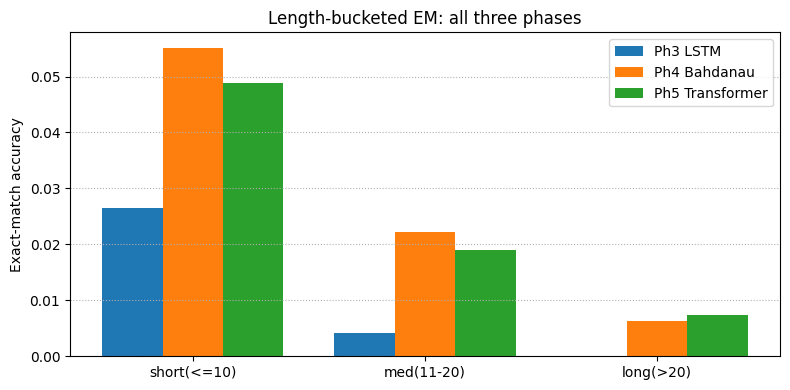

In [16]:
import matplotlib.pyplot as plt
import numpy as np


def load_preds(tsv_path):
    srcs, preds, refs = [], [], []
    with open(tsv_path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 3:
                continue
            srcs.append(parts[0]); preds.append(parts[1]); refs.append(parts[2])
    return srcs, preds, refs


def all_metrics(preds, refs, srcs):
    em      = exact_match(preds, refs)
    gleu    = corpus_gleu([[r.split()] for r in refs], [p.split() for p in preds])
    p, r, f = token_prf(preds, refs, beta=0.5)
    buckets = length_bucketed_em(srcs, preds, refs)
    return {"EM": em, "GLEU": gleu, "P": p, "R": r, "F05": f, "buckets": buckets}


ph3_s, ph3_p, ph3_r = load_preds(f"{PH3_DIR}/test_predictions_greedy.tsv")
ph4_s, ph4_p, ph4_r = load_preds(f"{PH4_DIR}/test_predictions_greedy.tsv")
ph3_m = all_metrics(ph3_p, ph3_r, ph3_s)
ph4_m = all_metrics(ph4_p, ph4_r, ph4_s)
ph5_m = all_metrics(preds_greedy, refs_text, srcs_text)

print(f"{'Metric':<8} {'Phase3':>10} {'Phase4':>10} {'Phase5':>10} "
      f"{'P4-P3':>10} {'P5-P4':>10}")
for k in ["EM", "GLEU", "P", "R", "F05"]:
    print(f"{k:<8} {ph3_m[k]:>10.4f} {ph4_m[k]:>10.4f} {ph5_m[k]:>10.4f}"
          f" {ph4_m[k]-ph3_m[k]:>+10.4f} {ph5_m[k]-ph4_m[k]:>+10.4f}")

# Length-bucketed bar chart
bks = list(ph3_m["buckets"].keys())
v3  = [ph3_m["buckets"][k][0] for k in bks]
v4  = [ph4_m["buckets"][k][0] for k in bks]
v5  = [ph5_m["buckets"][k][0] for k in bks]
x   = np.arange(len(bks)); w = 0.26

plt.figure(figsize=(8, 4))
plt.bar(x - w, v3, w, label="Ph3 LSTM")
plt.bar(x,      v4, w, label="Ph4 Bahdanau")
plt.bar(x + w,  v5, w, label="Ph5 Transformer")
plt.xticks(x, bks)
plt.ylabel("Exact-match accuracy")
plt.title("Length-bucketed EM: all three phases")
plt.legend(); plt.grid(axis="y", linestyle=":")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/three_way_compare.png", dpi=150)
plt.show()

## 11. Attention visualisation

We capture two attention maps from the **last encoder layer** and **last decoder layer**
using PyTorch forward hooks:

- **Encoder self-attention**: each source token attends to all other source tokens.
  In GEC this reveals which context the model uses to judge a given token — e.g.,
  a verb should attend to its subject to check agreement.
- **Decoder cross-attention** (encoder-decoder attention): each generated output token
  queries the source. This is the direct analogue of Bahdanau attention.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


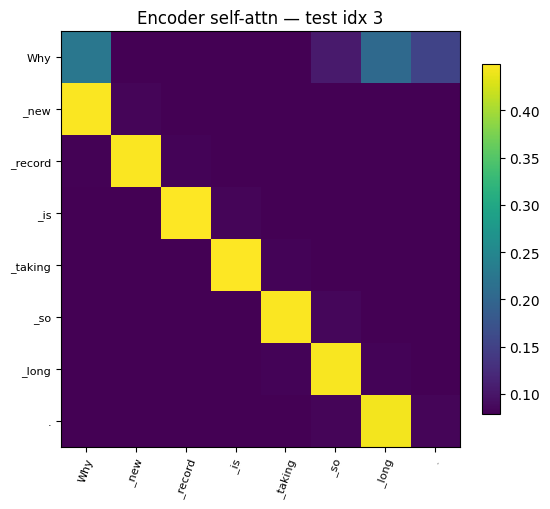

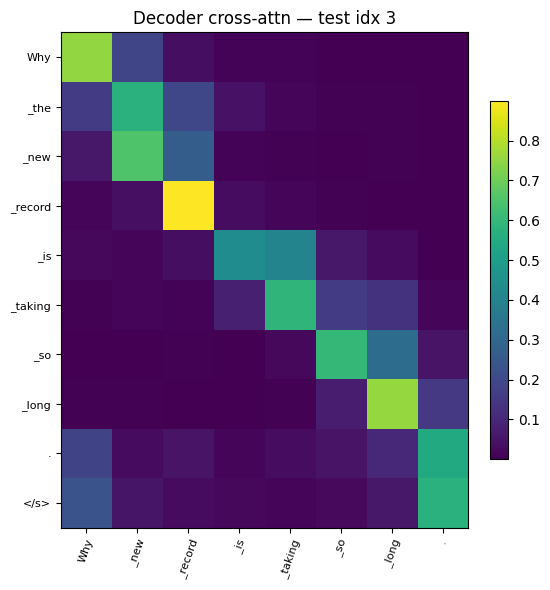

[3] SRC : Why new record is taking so long.
     REF : Why the new record is taking so long.
     PRED: Why new record is taking so long?



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


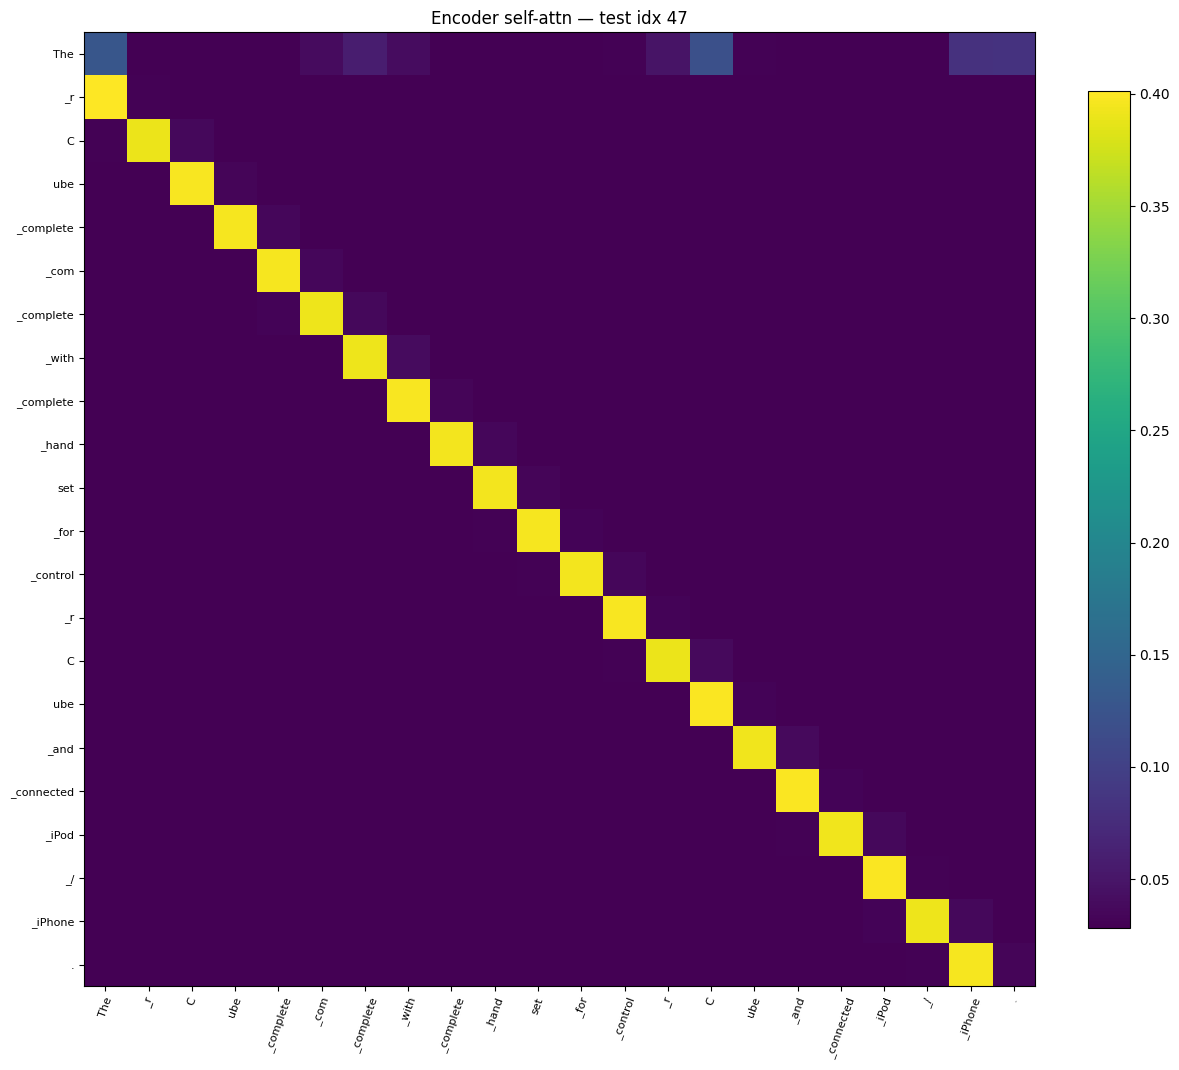

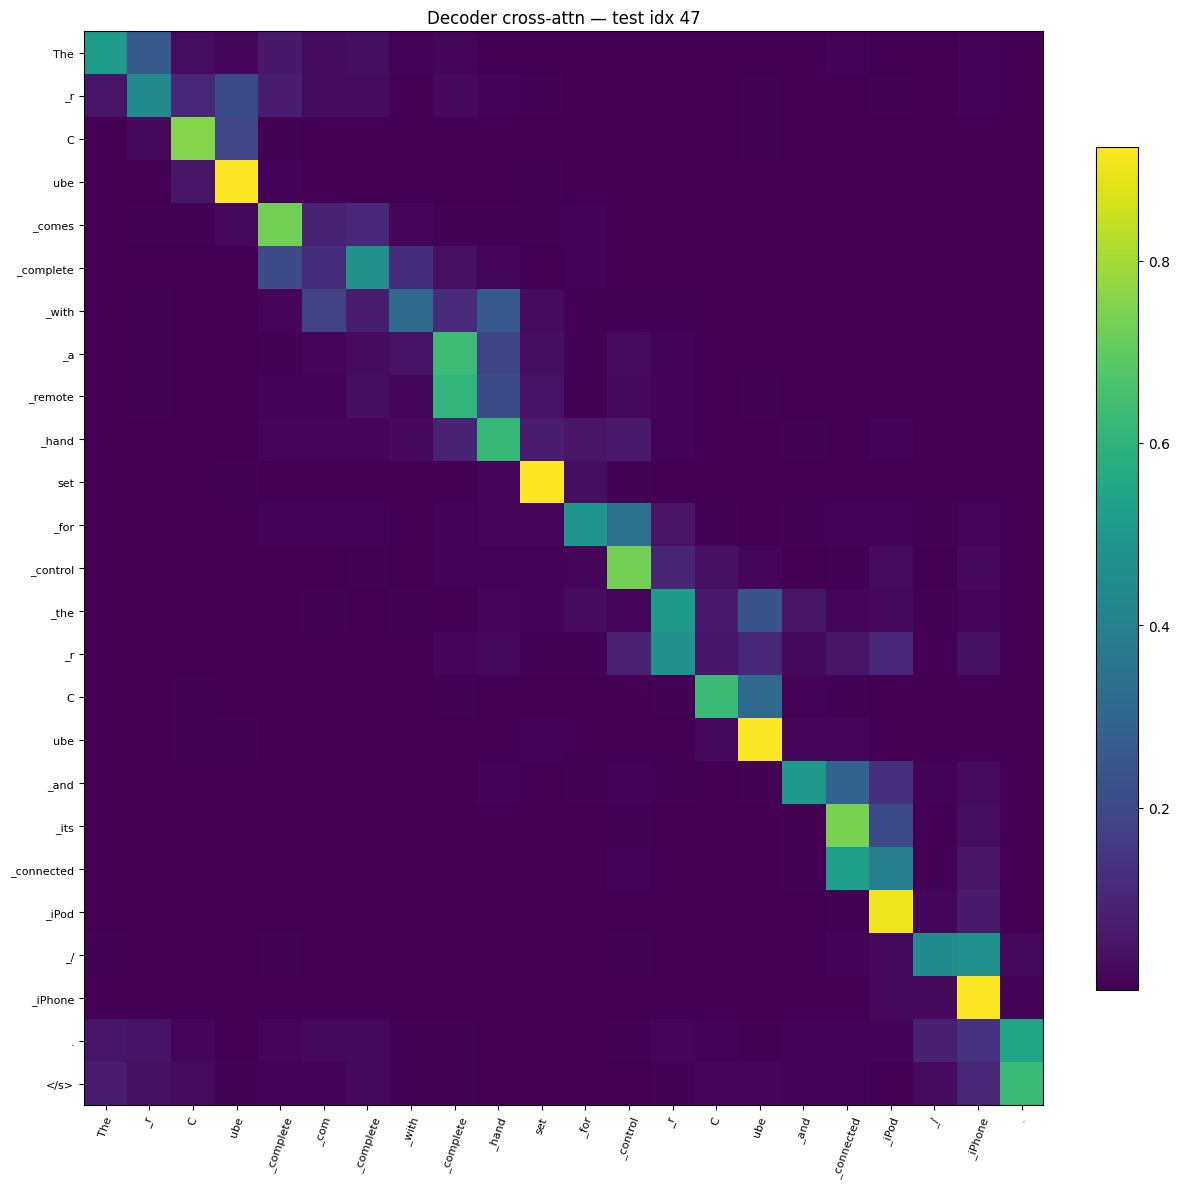

[47] SRC : The rCube complete com complete with complete handset for control rCube and connected iPod / iPhone.
     REF : The rCube comes complete with a remote handset for control the rCube and its connected iPod / iPhone.
     PRED: The rCube complete complete handset for control rCube and connected iPod / iPhone.



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


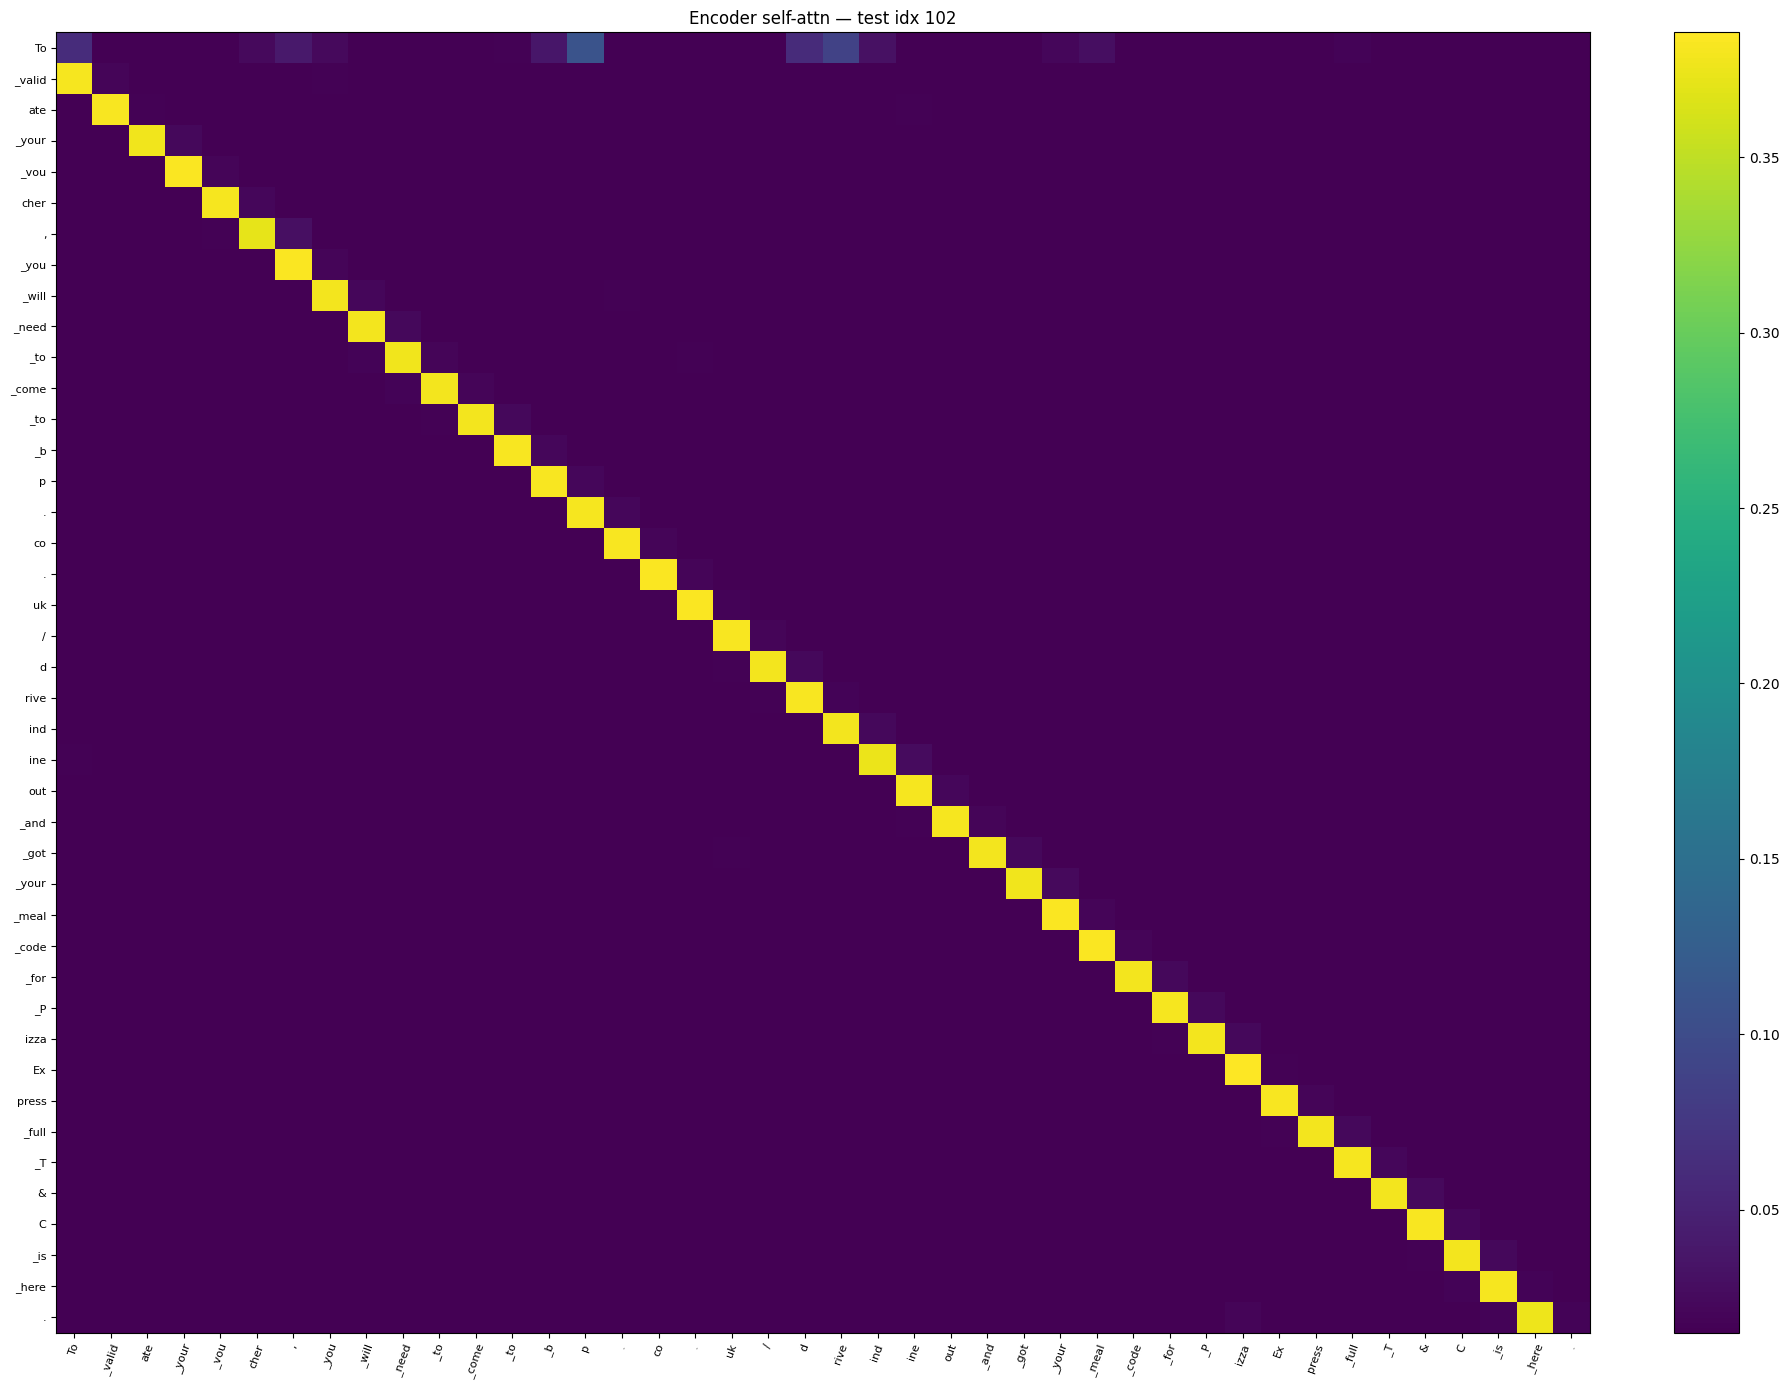

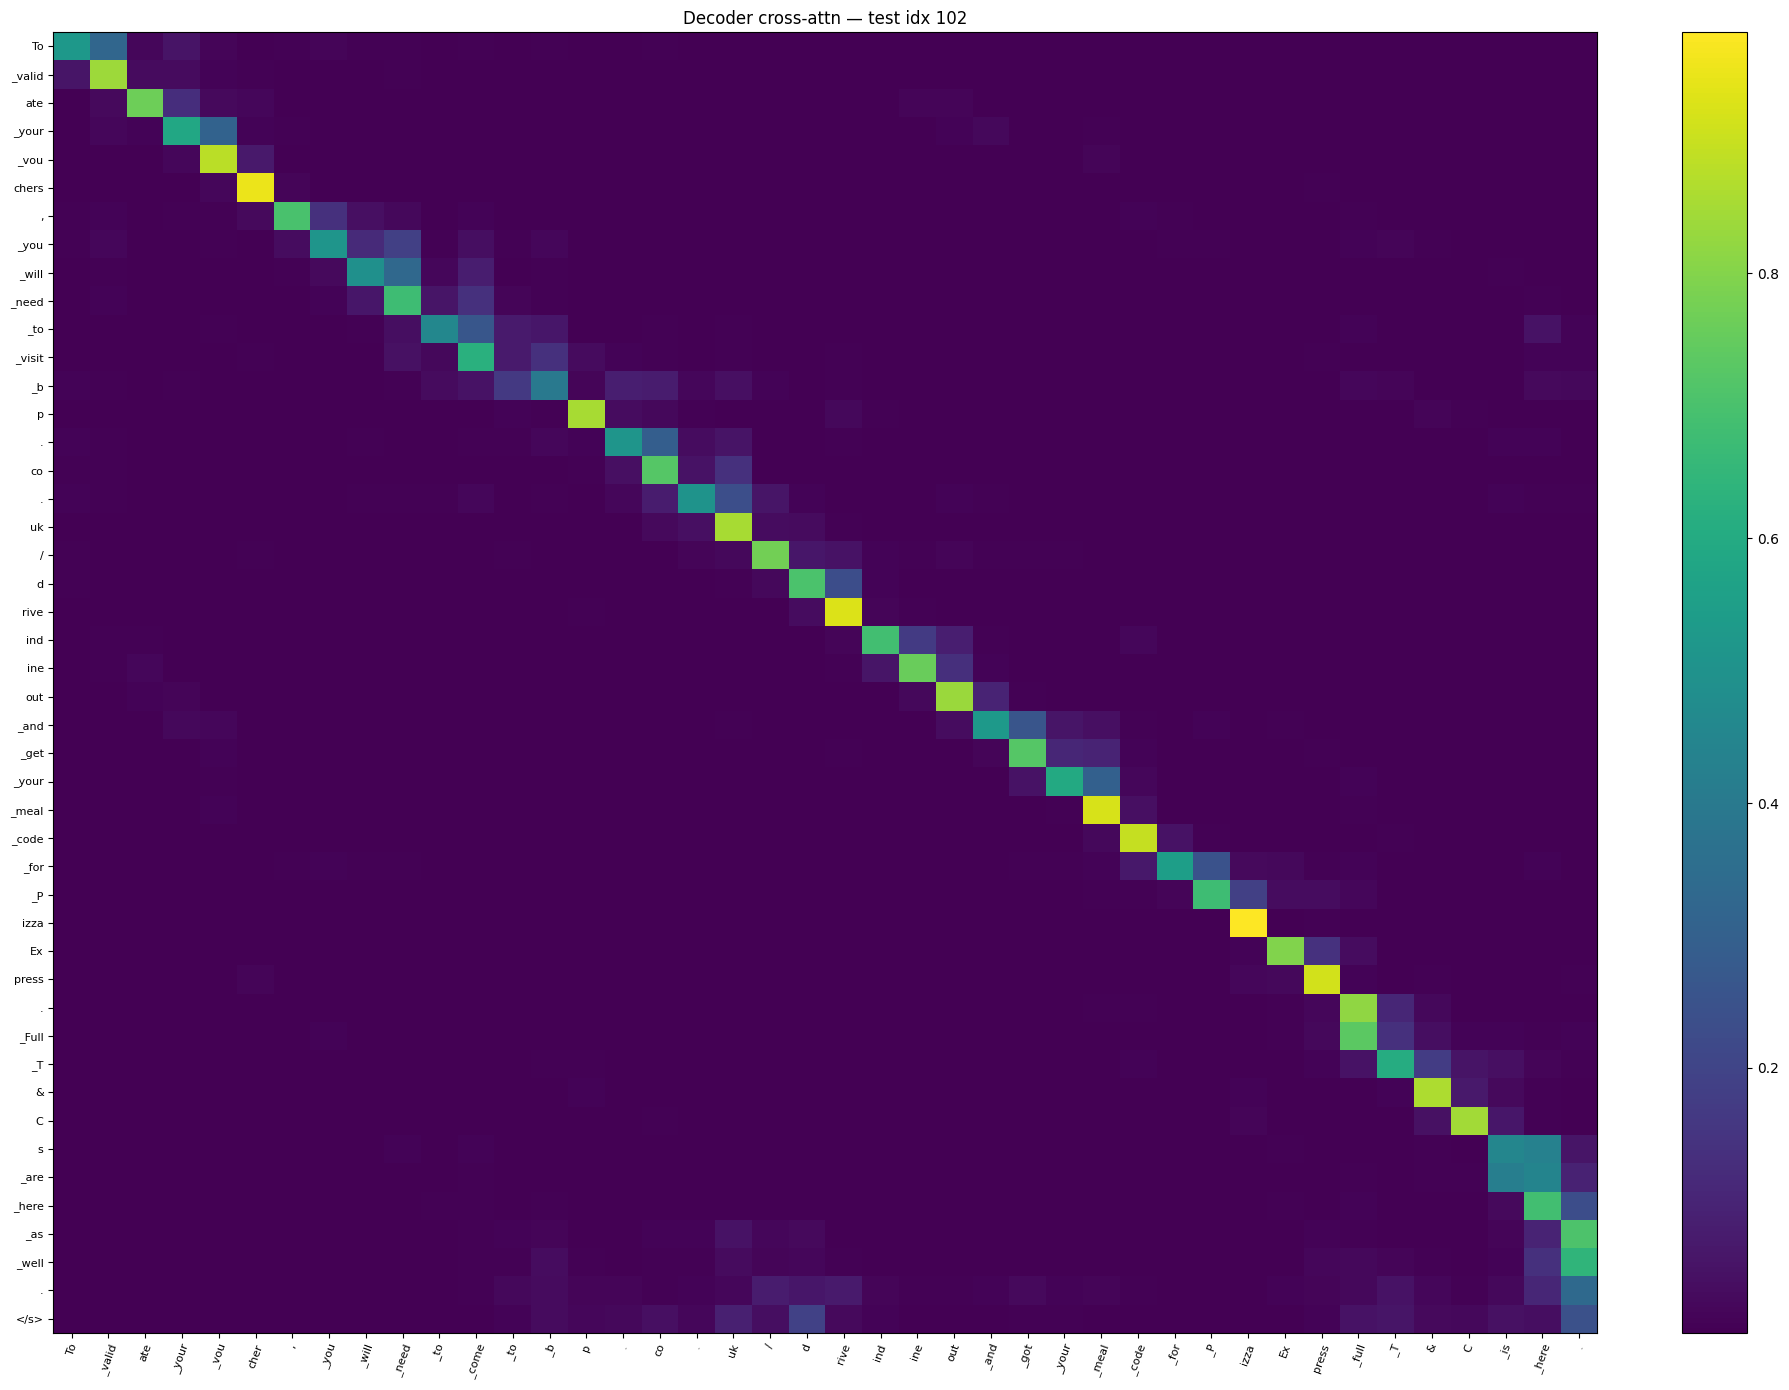

[102] SRC : To validate your voucher, you will need to come to bp.co.uk/driveindineout and got your meal code for PizzaExpress full T&C is here.
     REF : To validate your vouchers, you will need to visit bp.co.uk/driveindineout and get your meal code for PizzaExpress. Full T&Cs are here as well.
     PRED: To validate your voucher, you will need to come to bp.co.uk/driveindineout and get your meal code for PizzaExpress full T&C is here.



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


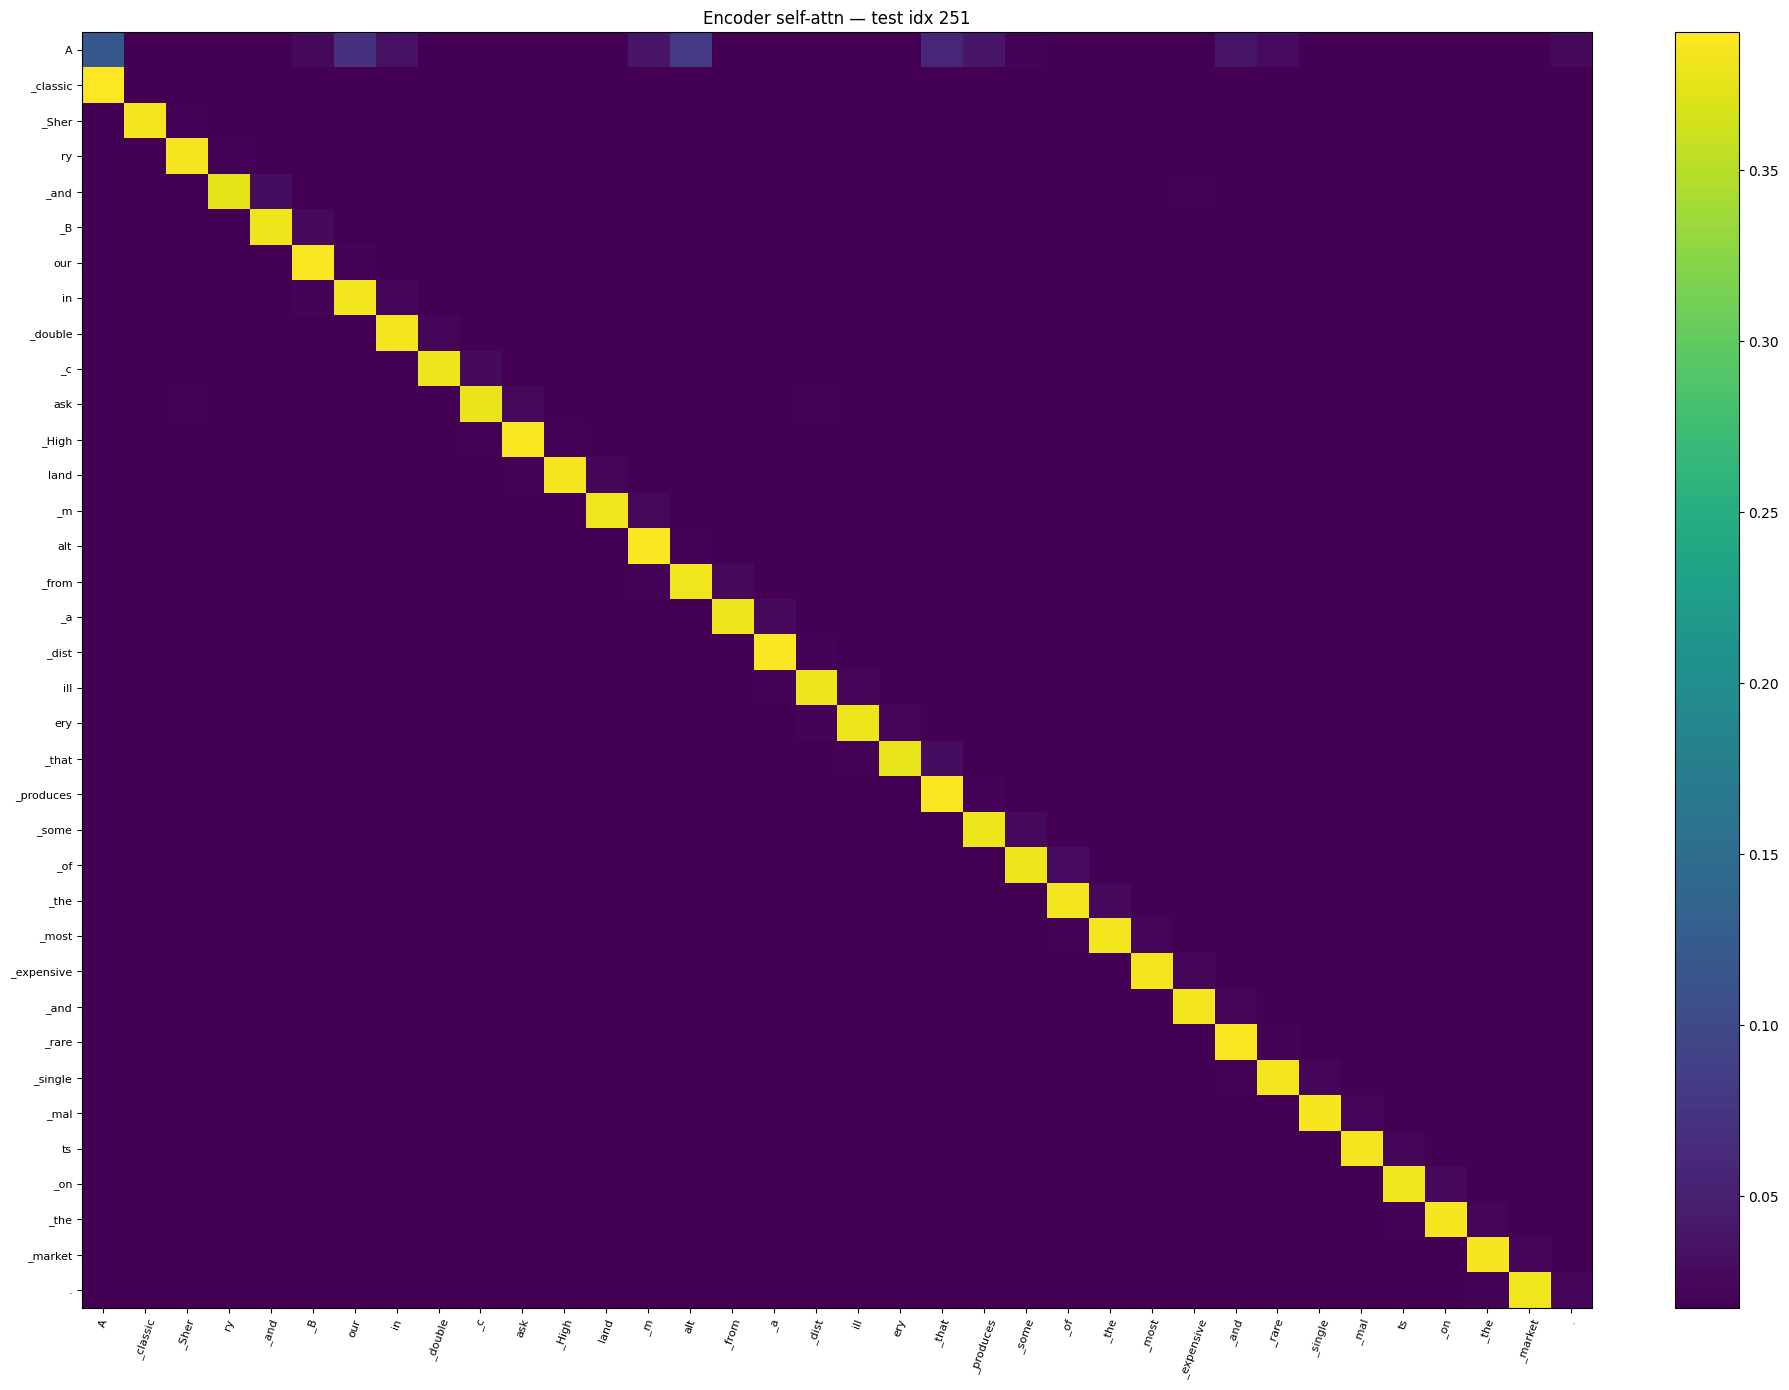

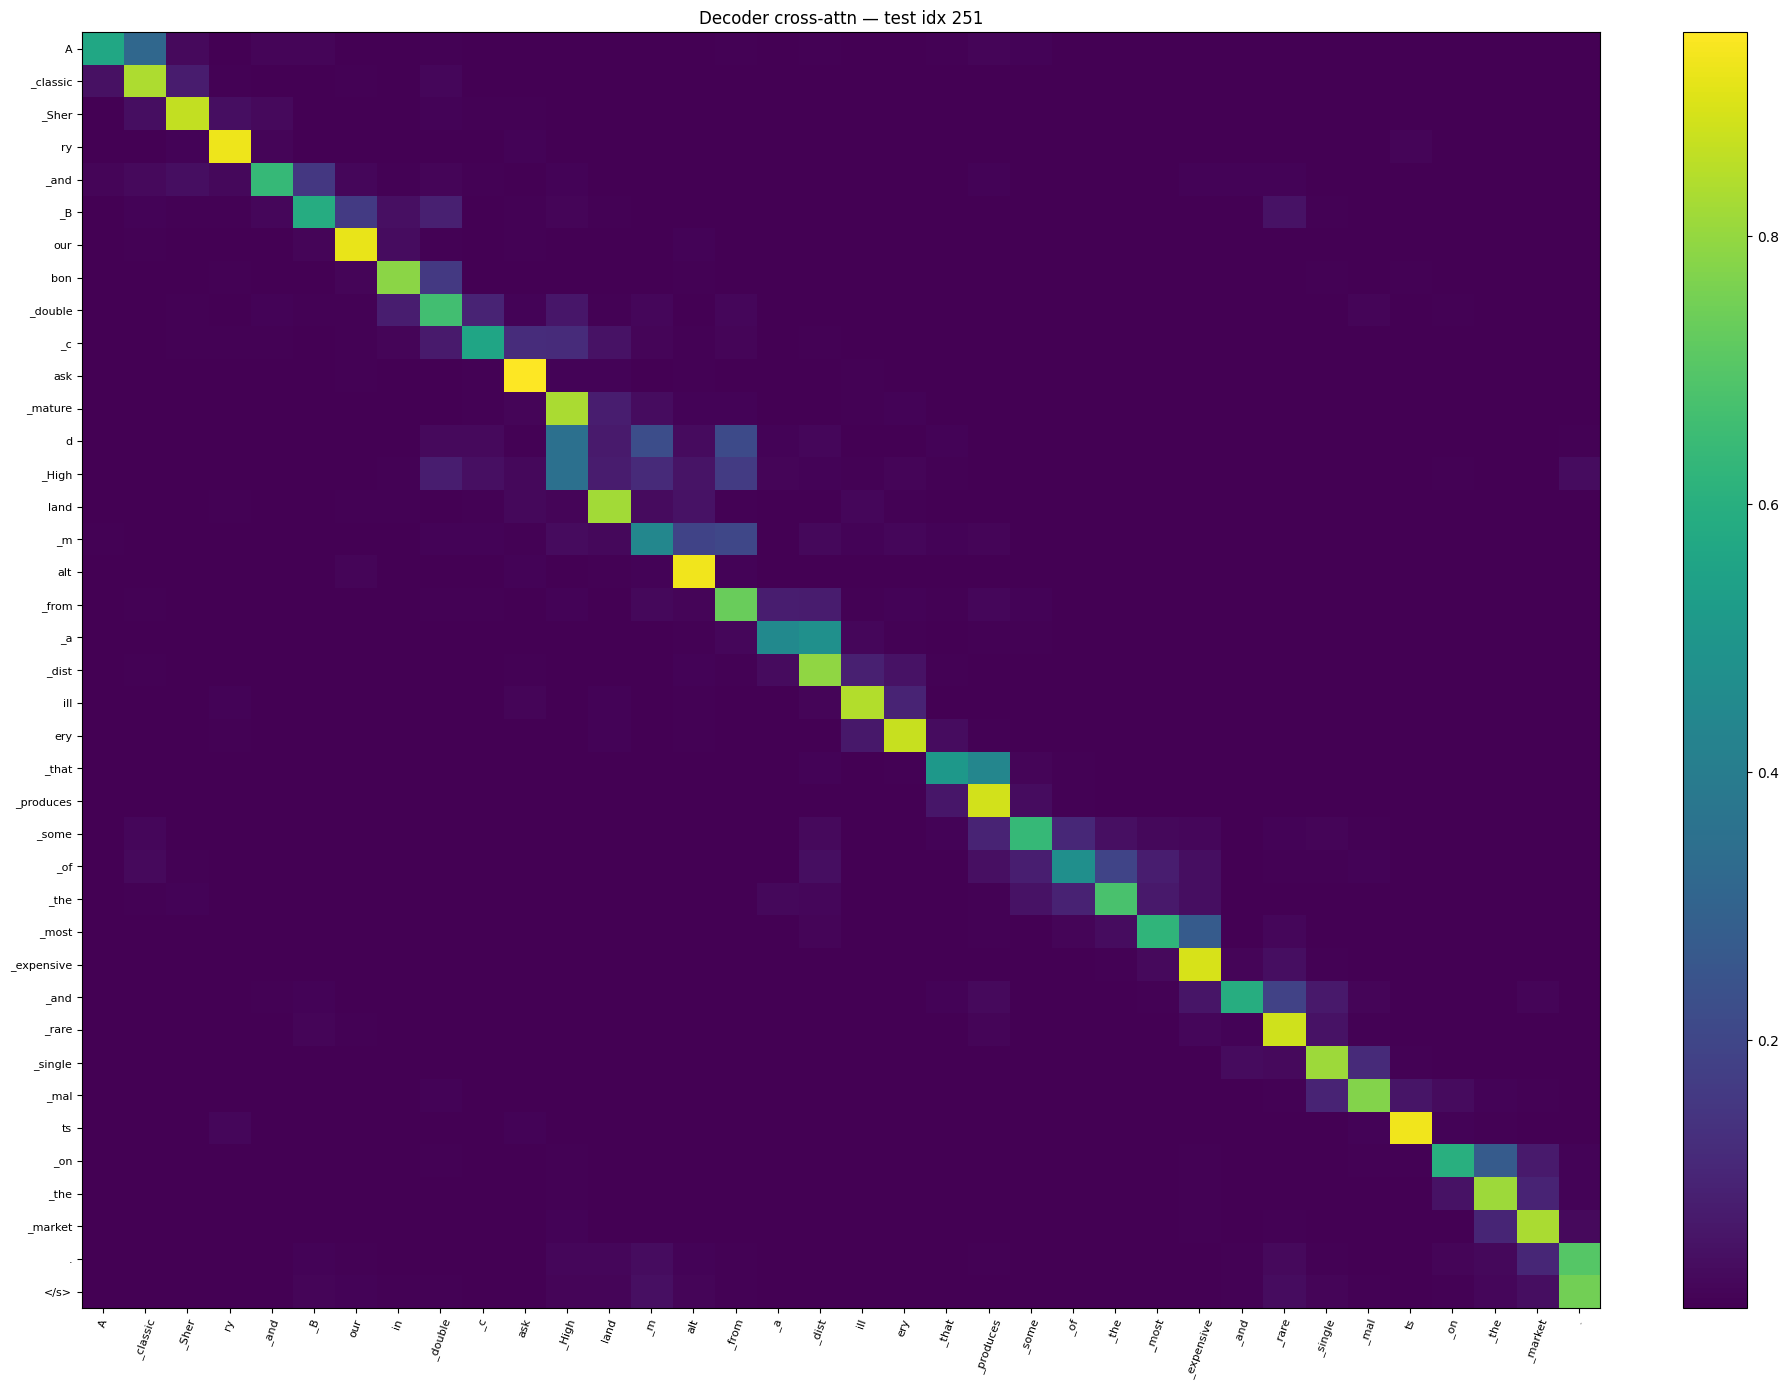

[251] SRC : A classic Sherry and Bourin double cask Highland malt from a distillery that produces some of the most expensive and rare single malts on the market.
     REF : A classic Sherry and Bourbon double cask matured Highland malt from a distillery that produces some of the most expensive and rare single malts on the market.
     PRED: A classic Sherry and Bourin double cask Highland malt from a distillery that produces some of the most expensive and rare single malts on the market.



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


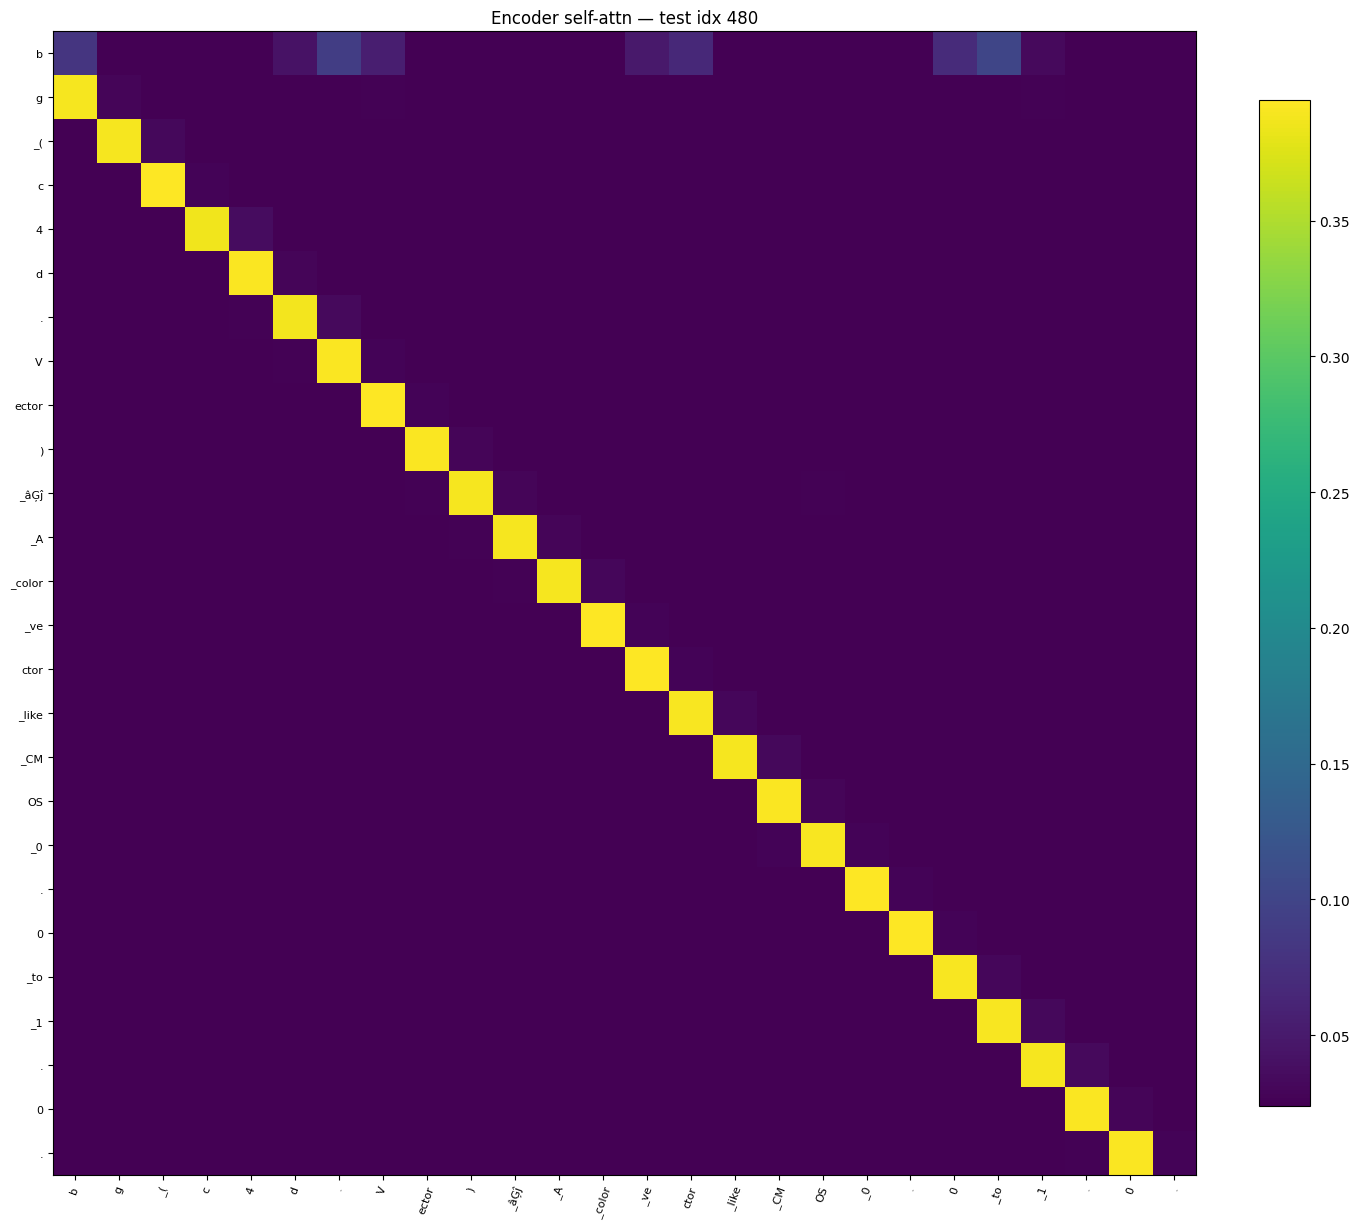

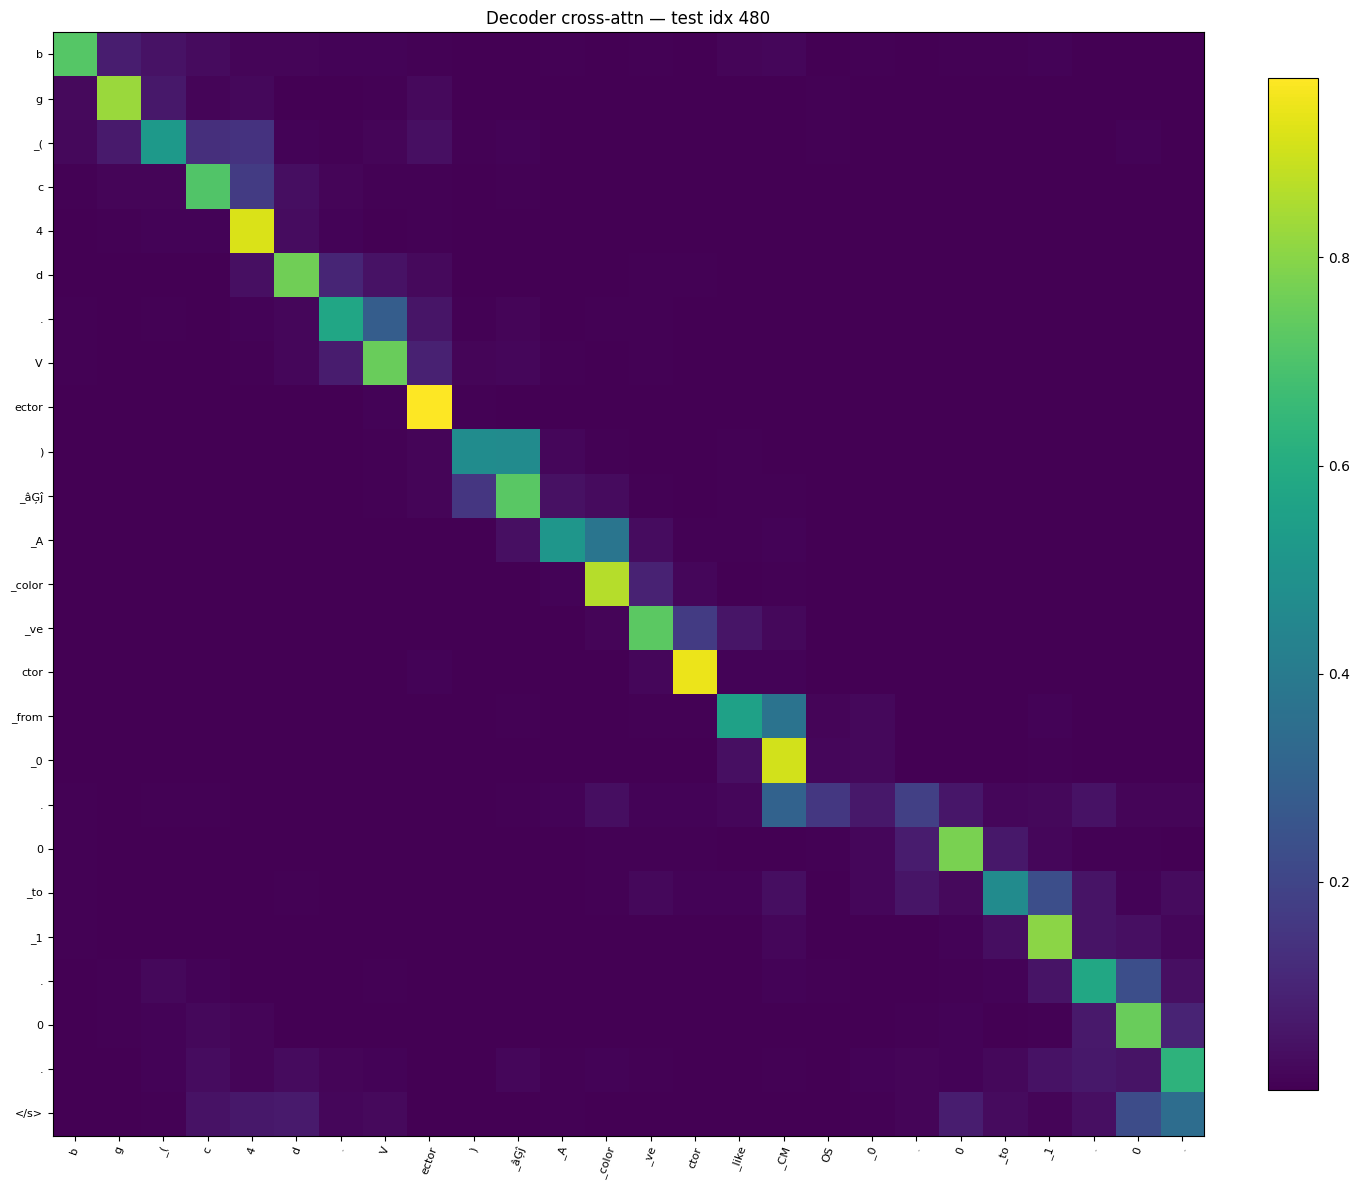

[480] SRC : bg (c4d.Vector) – A color vector like CMOS 0.0 to 1.0.
     REF : bg (c4d.Vector) – A color vector from 0.0 to 1.0.
     PRED: bg (c4d.Vector) – A color vector like CMOS 0.0 to 1.0.



In [17]:
def pretty_tok(tok_id):
    t = tokenizer.id_to_token(int(tok_id))
    return t.replace("Ġ", "_") if t else "?"


def get_attn_maps(model, src_ids, tgt_ids):
    """Teacher-forced forward pass, returns last-layer enc self-attn and dec cross-attn.

    Why the old monkey-patch failed: under eval() + no_grad() with post-LN layers,
    nn.TransformerEncoder/DecoderLayer take a fused C++ fast path that never calls
    _sa_block / _mha_block, so the patched functions were dead code and the capture
    lists stayed [None] -> 'NoneType' object is not subscriptable.

    Fix: (1) register real forward hooks on the MultiheadAttention modules,
    (2) force need_weights=True via a kwargs-rewriting pre-hook,
    (3) flip the layers' training flag so PyTorch stays on the Python path
        (the fast path requires training=False). Dropout is zeroed so the maps
        stay deterministic; no trained weights are modified.
    """
    enc_self, dec_cross = [None], [None]

    enc_mha = model.transformer.encoder.layers[-1].self_attn
    dec_mha = model.transformer.decoder.layers[-1].multihead_attn

    def pre_hook(module, args, kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = True
        return args, kwargs

    def make_hook(store):
        def hook(module, inputs, output):
            if isinstance(output, tuple) and len(output) == 2 and output[1] is not None:
                store[0] = output[1].detach().cpu()
        return hook

    h1 = enc_mha.register_forward_pre_hook(pre_hook, with_kwargs=True)
    h2 = enc_mha.register_forward_hook(make_hook(enc_self))
    h3 = dec_mha.register_forward_pre_hook(pre_hook, with_kwargs=True)
    h4 = dec_mha.register_forward_hook(make_hook(dec_cross))

    model.eval()

    # Force the Python path: the fused fast path needs training=False, so set the
    # transformer layers' training flag True while zeroing all dropout so output
    # stays deterministic. Save/restore so we don't leave the model dirty.
    saved_training = {}
    saved_dropout  = {}
    for name, m in model.named_modules():
        if isinstance(m, (nn.TransformerEncoderLayer, nn.TransformerDecoderLayer)):
            saved_training[name] = m.training
            m.training = True
        if isinstance(m, nn.Dropout):
            saved_dropout[name] = m.p
            m.p = 0.0

    src = src_ids.unsqueeze(0).to(DEVICE)
    tgt = tgt_ids.unsqueeze(0).to(DEVICE)
    try:
        with torch.no_grad():
            model(src, tgt[:, :-1])
    finally:
        for name, m in model.named_modules():
            if name in saved_training:
                m.training = saved_training[name]
            if name in saved_dropout:
                m.p = saved_dropout[name]
        h1.remove(); h2.remove(); h3.remove(); h4.remove()

    if enc_self[0] is None or dec_cross[0] is None:
        raise RuntimeError(
            "Attention weights not captured — fast path still ran. "
            "Check torch version / layer types."
        )

    # average_attn_weights=True -> shape (B, L, S); drop the batch dim
    return enc_self[0][0].numpy(), dec_cross[0][0].numpy()


def plot_attn(matrix, x_labels, y_labels, title, save_path):
    fig, ax = plt.subplots(
        figsize=(min(0.45 * len(x_labels) + 2, 18),
                 min(0.40 * len(y_labels) + 2, 14)))
    im = ax.imshow(matrix, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=70, fontsize=8)
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


PICKS = [3, 47, 102, 251, 480]

for idx in PICKS:
    if idx >= len(test_ds):
        continue
    src_t, tgt_t = test_ds[idx]
    enc_attn, dec_attn = get_attn_maps(model, src_t, tgt_t)

    src_labels = [pretty_tok(i) for i in src_t.tolist()]
    tgt_labels = [pretty_tok(i) for i in tgt_t.tolist()[1:]]  # skip BOS

    # Encoder self-attention (square matrix)
    plot_attn(enc_attn, src_labels, src_labels,
              f"Encoder self-attn — test idx {idx}",
              f"{OUT_DIR}/enc_self_attn_{idx}.png")

    # Decoder cross-attention (T_tgt × T_src)
    T_tgt = min(dec_attn.shape[0], len(tgt_labels))
    plot_attn(dec_attn[:T_tgt], src_labels, tgt_labels[:T_tgt],
              f"Decoder cross-attn — test idx {idx}",
              f"{OUT_DIR}/dec_cross_attn_{idx}.png")

    print(f"[{idx}] SRC : {ids_to_text(src_t.tolist())}")
    print(f"     REF : {ids_to_text(tgt_t.tolist())}")
    print(f"     PRED: {preds_greedy[idx]}\n")

## 12. Qualitative examples

Automatically find test cases where Phase 5 (Transformer) produces the exact reference
but Phase 4 (Bahdanau) did not — these show the concrete gains from full attention.

In [18]:
print("=" * 60)
print("Phase 5 wins (P5 == ref, P4 != ref)")
print("=" * 60)
shown = 0
for s, p4, p5, r in zip(ph4_s, ph4_p, preds_greedy, refs_text):
    if p5.strip() == r.strip() and p4.strip() != r.strip():
        print(f"SRC : {s}")
        print(f"P4  : {p4}")
        print(f"P5  : {p5}")
        print(f"REF : {r}\n")
        shown += 1
        if shown >= 10:
            break
if shown == 0:
    print("No exact-match wins — compare GLEU per sentence instead.")

# Also sample 10 random examples
print("\n" + "=" * 60)
print("Random sample (greedy)")
print("=" * 60)
random.seed(0)
indices = random.sample(range(len(srcs_text)), min(10, len(srcs_text)))
for i in indices:
    print(f"[{i}] SRC : {srcs_text[i]}")
    print(f"     PRED: {preds_greedy[i]}")
    print(f"     REF : {refs_text[i]}")
    print(f"     match={'✓' if preds_greedy[i].strip()==refs_text[i].strip() else '✗'}\n")

Phase 5 wins (P5 == ref, P4 != ref)
SRC : McCrory, R., Putnam, R. & Jansen, A. (2008). Interaction in Online Courses for Teacher Education: Subject Matter and Pedagogy. Journal of Technology and Teacher Education, 16 (2), 155-180. Waynesville, NC usa
P4  : McCrory, R., Putnam, R. & Jansen, A. (2008). Interaction in Online Course for Teacher Education: Subject Matter and Pedagogy. Journal of Technology and Teacher Education, 16 (2), 155-180. Waynesville, NC
P5  : McCrory, R., Putnam, R. & Jansen, A. (2008). Interaction in Online Courses for Teacher Education: Subject Matter and Pedagogy. Journal of Technology and Teacher Education, 16 (2), 155-180. Waynesville, NC
REF : McCrory, R., Putnam, R. & Jansen, A. (2008). Interaction in Online Courses for Teacher Education: Subject Matter and Pedagogy. Journal of Technology and Teacher Education, 16 (2), 155-180. Waynesville, NC

SRC : Part of Bearfoots by Jeff Fleming. From To Big Sky Carvers.
P4  : Part of Bearfoots by Jeff Fleming From From 

## 13. Save run summary

In [19]:
ph3_sum = json.load(open(f"{PH3_DIR}/summary.json"))
ph4_sum = json.load(open(f"{PH4_DIR}/summary.json"))

summary = {
    "model":          "transformer_gec",
    "params_M":       round(n_params / 1e6, 2),
    "config":         CFG,
    "best_val_gleu":  best_gleu,
    "test": {
        "greedy": {
            "exact_match": exact_match(preds_greedy, refs_text),
            "gleu":        corpus_gleu([[r.split()] for r in refs_text],
                                       [p.split() for p in preds_greedy]),
        },
        "beam4": {
            "n_samples":   _beam_n,
            "exact_match": exact_match(preds_beam, refs_text[:_beam_n]),
            "gleu":        corpus_gleu([[r.split()] for r in refs_text[:_beam_n]],
                                       [p.split() for p in preds_beam]),
        },
    },
    "compare_to_phase3": {
        "EM_delta":   ph5_m["EM"]   - ph3_m["EM"],
        "GLEU_delta": ph5_m["GLEU"] - ph3_m["GLEU"],
    },
    "compare_to_phase4": {
        "EM_delta":   ph5_m["EM"]   - ph4_m["EM"],
        "GLEU_delta": ph5_m["GLEU"] - ph4_m["GLEU"],
    },
}
with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

print("\nFiles in OUT_DIR:")
for fn in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, fn))
    print(f"  {fn}  ({size/1e6:.1f} MB)")

{
  "model": "transformer_gec",
  "params_M": 8.05,
  "config": {
    "vocab_size": 16000,
    "d_model": 256,
    "nhead": 8,
    "num_enc_layers": 3,
    "num_dec_layers": 3,
    "dim_ffn": 512,
    "dropout": 0.1,
    "max_len": 64,
    "batch_size": 64,
    "lr_peak": 0.001,
    "warmup_steps": 4000,
    "weight_decay": 0.0001,
    "clip": 1.0,
    "label_smooth": 0.1,
    "epochs": 10,
    "log_every": 200,
    "ckpt_every": 2000,
    "max_train": 850000,
    "max_val": 50000,
    "max_test": 100000,
    "max_val_eval": 5000,
    "max_beam_eval": 2000
  },
  "best_val_gleu": 0.6131024347536063,
  "test": {
    "greedy": {
      "exact_match": 0.021658823529411765,
      "gleu": 0.6180555319717138
    },
    "beam4": {
      "n_samples": 2000,
      "exact_match": 0.02,
      "gleu": 0.6183130064884366
    }
  },
  "compare_to_phase3": {
    "EM_delta": 0.013623529411764706,
    "GLEU_delta": 0.4052538821526875
  },
  "compare_to_phase4": {
    "EM_delta": -0.002223529411764704,
  